# Оценка эффективности флэшмоба с помощью CausalImpact

## tl;dr

Флэшмоб проходил **10–16 июля 2026 года**. По базовой модели курса:

- `DAU` — значимо не изменился; ближайший вариант среднего эффекта: **850**;
- `CTR` — значимо вырос; эффект: **0.01**;
- просмотры — значимо выросли; эффект: **659855** просмотров в день;
- новые посты — значимо не изменились; эффект: **8** постов в день;
- уникальные просматриваемые посты — значимо выросли; эффект: **76** постов в день.

После завершения флэшмоба метрики вернулись к обычной траектории: устойчивого долгосрочного эффекта не видно.

> Числа модели немного меняются между запусками, потому что `tfcausalimpact` использует вероятностное приближение. В LMS нужно выбирать ближайший предложенный вариант.

## Context & Methods

**Источник:** ClickHouse, таблица `simulator_20260720.feed_actions`, проверенная в Redash 1 августа 2026 года.

**Периоды:**

- пре-период: 30 мая — 9 июля;
- период воздействия: 10–16 июля;
- период после мероприятия: 17–31 июля.

Для ответа в LMS используется базовый `CausalImpact` без ковариат, сезонности и отдельного глобального тренда — именно такую постановку требует шаг 8. Это учебная квазиэкспериментальная оценка: без контрольного ряда причинный вывод слабее, чем в A/B-тесте.

### Key Assumptions

1. До 10 июля не происходило других крупных изменений, одновременно влияющих на метрики.
2. Паттерны пре-периода пригодны для построения контрфактического прогноза.
3. «Новый пост» — пост в день его первого появления в `feed_actions`. В таблице нет отдельного времени создания поста, поэтому это приближение.

In [1]:
import os
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from causalimpact import CausalImpact

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

cwd = Path.cwd()
if (cwd / "data" / "flashmob_daily_metrics.csv").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "flashmob_daily_metrics.csv").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Не найден файл data/flashmob_daily_metrics.csv")

DATA_PATH = PROJECT_ROOT / "data" / "flashmob_daily_metrics.csv"
SQL_PATH = PROJECT_ROOT / "sql" / "flashmob_daily_metrics.sql"

PRE_START = "2026-05-30"
PRE_END = "2026-07-09"
POST_START = "2026-07-10"
POST_END = '2026-07-16'

## Data

### 1. Загружаем дневную витрину

Одна строка — один календарный день. `CTR` рассчитывается как отношение всех лайков ко всем просмотрам за день, а не как невзвешенное среднее пользовательских CTR.

In [2]:
metrics = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date")
metrics.head()

,dau,likes,views,ctr,unique_viewed_posts,new_posts
date,,,,,,
2026-05-30,878,1560,7603,0.2052,89,89
2026-05-31,2238,12816,62770,0.2042,178,97
2026-06-01,3105,20958,105526,0.1986,191,61
2026-06-02,3721,23800,118996,0.2000,211,87
2026-06-03,4617,34504,174454,0.1978,214,70


### 2. Проверяем качество данных

Проверяем непрерывность календаря, уникальность дневного зерна, допустимые диапазоны и формулу `CTR`. Неполный день 1 августа в выгрузку не включён.

In [3]:
expected_dates = pd.date_range(metrics.index.min(), metrics.index.max(), freq="D")
missing_dates = expected_dates.difference(metrics.index)

quality_checks = pd.Series({
    "строк": len(metrics),
    "дубликатов дат": int(metrics.index.duplicated().sum()),
    "пропущенных дат": len(missing_dates),
    "пропусков в показателях": int(metrics.isna().sum().sum()),
    "дней с views <= 0": int((metrics["views"] <= 0).sum()),
    "дней с CTR вне [0, 1]": int((~metrics["ctr"].between(0, 1)).sum()),
    "максимальная ошибка CTR": float(
        (metrics["ctr"] - metrics["likes"] / metrics["views"]).abs().max()
    ),
})

assert quality_checks["дубликатов дат"] == 0
assert quality_checks["пропущенных дат"] == 0
assert quality_checks["пропусков в показателях"] == 0
assert quality_checks["дней с views <= 0"] == 0
assert quality_checks["дней с CTR вне [0, 1]"] == 0
assert quality_checks["максимальная ошибка CTR"] < 1e-8

quality_checks.to_frame("значение")

,значение
строк,63.0000
дубликатов дат,0.0000
пропущенных дат,0.0000
пропусков в показателях,0.0000
дней с views <= 0,0.0000
"дней с CTR вне [0, 1]",0.0000
максимальная ошибка CTR,0.0000


### 3. Смотрим временные ряды

Вертикальная область показывает период флэшмоба. На просмотрах и уникальных постах заметен скачок, а `DAU` продолжает общую растущую траекторию.

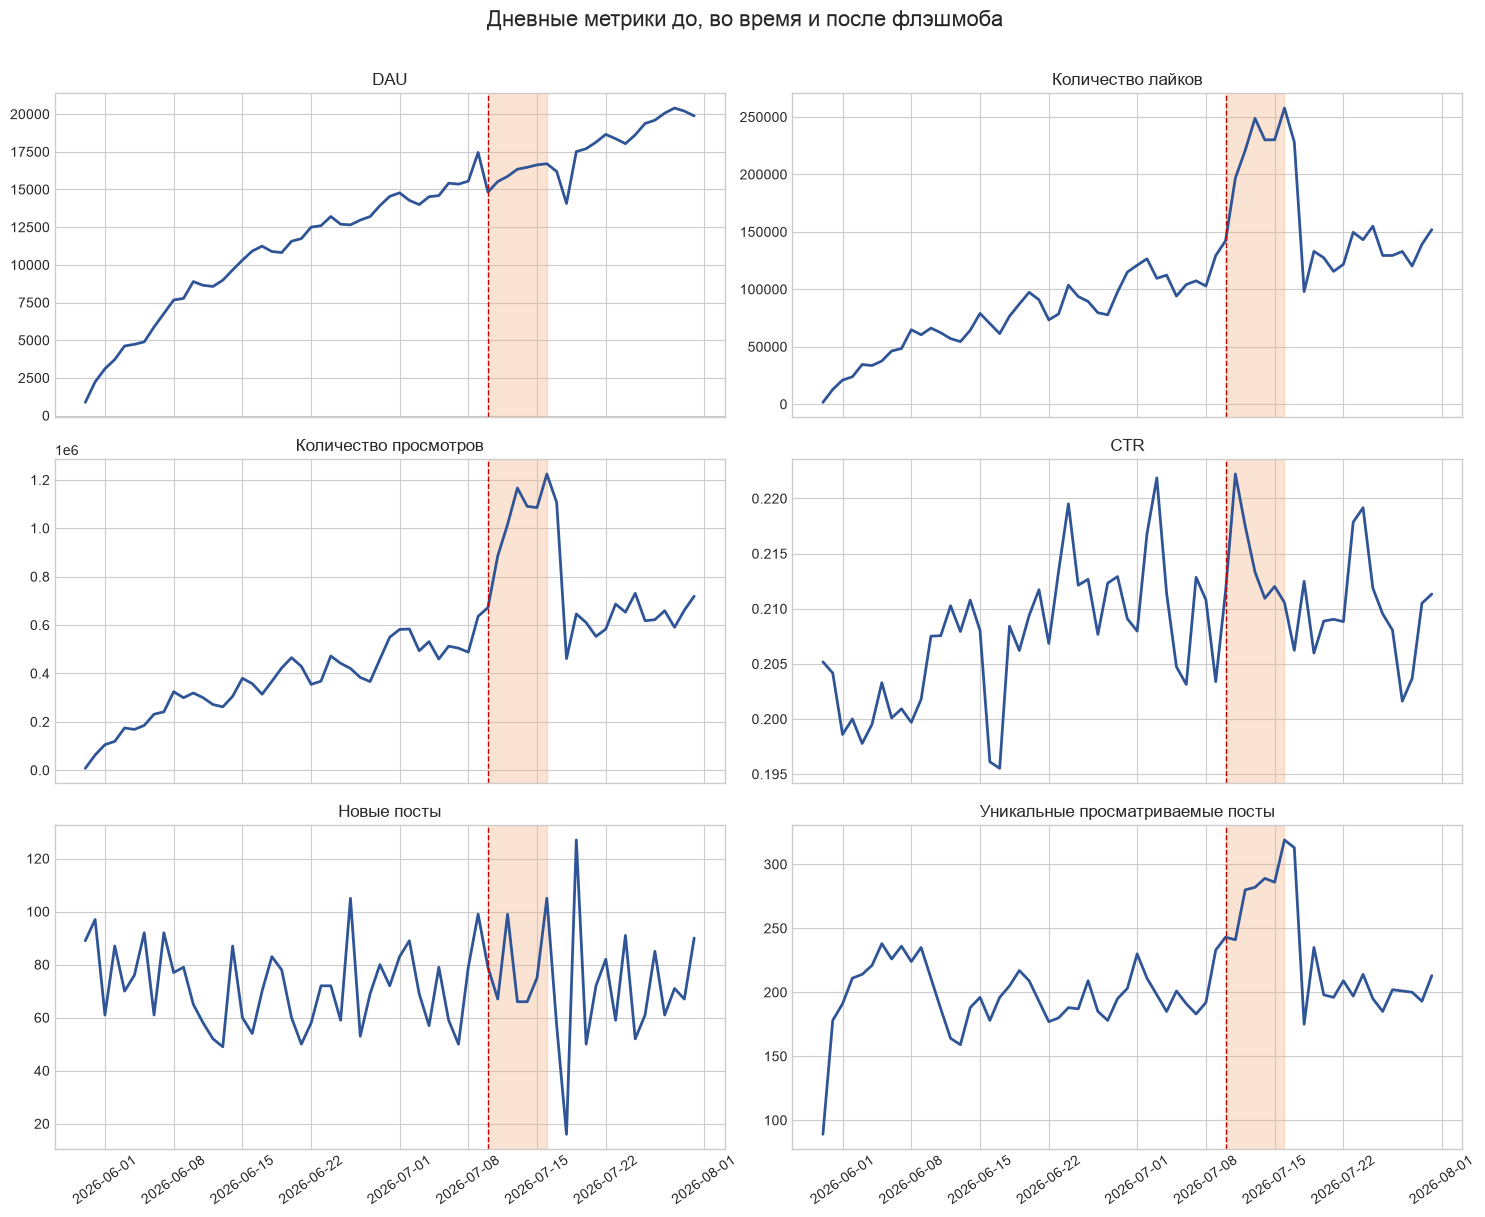

In [4]:
plot_metrics = ["dau", "likes", "views", "ctr", "new_posts", "unique_viewed_posts"]
titles = {
    "dau": "DAU",
    "likes": "Количество лайков",
    "views": "Количество просмотров",
    "ctr": "CTR",
    "new_posts": "Новые посты",
    "unique_viewed_posts": "Уникальные просматриваемые посты",
}

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
for ax, metric in zip(axes.flat, plot_metrics):
    ax.plot(metrics.index, metrics[metric], color="#2F5597", linewidth=2)
    ax.axvspan(pd.Timestamp(POST_START), pd.Timestamp(POST_END), color="#F4B183", alpha=0.35)
    ax.axvline(pd.Timestamp(POST_START), color="#C00000", linestyle="--", linewidth=1)
    ax.set_title(titles[metric])
    ax.tick_params(axis="x", rotation=35)

fig.suptitle("Дневные метрики до, во время и после флэшмоба", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

### 4. Проверяем глобальный тренд

Сравниваем линейный наклон в пре-периоде. Яркий глобальный рост наблюдается у `DAU` и количества лайков. `CTR` и число уникальных просматриваемых постов колеблются вокруг относительно стабильного уровня.

In [5]:
pre_data = metrics.loc[PRE_START:PRE_END]
trend_rows = []

for metric in ["likes", "dau", "unique_viewed_posts", "ctr"]:
    x = np.arange(len(pre_data))
    slope = np.polyfit(x, pre_data[metric].to_numpy(), 1)[0]
    trend_rows.append({
        "metric": metric,
        "наклон за день": slope,
        "наклон, % от среднего за день": slope / pre_data[metric].mean() * 100,
    })

trend_table = pd.DataFrame(trend_rows).set_index("metric")
trend_table

,наклон за день,"наклон, % от среднего за день"
metric,,
likes,"2,465.5481",3.2961
dau,337.5476,3.2283
unique_viewed_posts,0.0970,0.0492
ctr,0.0003,0.1415


### Ответы на теоретические шаги 2–7

**Шаг 2. Какие метрики доступны и осмысленны:**

- `CTR`;
- число лайков на пользователя;
- число просматриваемых постов;
- `DAU`.

Не выбираем абстрактную «заинтересованность», возраст уже зарегистрированных пользователей и комментарии, которых нет в `feed_actions`.

**Шаг 3. Пост-период:** `Весь период флэшмоба` — 10–16 июля. Недели после мероприятия нужны для отдельной проверки долгосрочного эффекта, но не должны размывать основной эффект.

**Шаг 4. Пре-период:** `2 недели и более`. Нужны как минимум несколько недельных циклов и достаточно наблюдений для контрфактического прогноза.

**Шаг 5. Почему стандартной модели недостаточно для почасовых данных:** `У нас есть выраженная внутридневная сезонность, не включённая в модель`.

**Шаг 6. Где виден глобальный тренд:** `Количество лайков` и `DAU`. Уникальные просматриваемые посты и `CTR` колеблются около сравнительно стабильного уровня.

**Шаг 7. Особенность DAU:** `Недельная сезонность`. Она может ухудшить прогноз базовой модели без сезонного компонента.

## Results

### 5. Запускаем базовый CausalImpact

Для каждой метрики модель обучается на пре-периоде и прогнозирует, каким был бы период 10–16 июля без флэшмоба. Эффект равен `факт − контрфактический прогноз`.

Если 95%-й интервал эффекта включает ноль, изменение считаем статистически незначимым.

In [6]:
def fit_causal_impact(metric: str):
    # Сброс seed делает вероятностное приближение максимально воспроизводимым.
    tf.keras.utils.set_random_seed(42)
    impact = CausalImpact(
        metrics[[metric]],
        [PRE_START, PRE_END],
        [POST_START, POST_END],
    )
    summary = impact.summary_data["average"]

    lower = float(summary["abs_effect_lower"])
    upper = float(summary["abs_effect_upper"])
    significant = not (lower <= 0 <= upper)

    if significant and summary["abs_effect"] > 0:
        conclusion = "значимо выросло"
    elif significant and summary["abs_effect"] < 0:
        conclusion = "значимо упало"
    else:
        conclusion = "значимо не изменилось"

    return impact, {
        "metric": metric,
        "факт": float(summary["actual"]),
        "прогноз без флэшмоба": float(summary["predicted"]),
        "средний эффект": float(summary["abs_effect"]),
        "нижняя граница 95%": lower,
        "верхняя граница 95%": upper,
        "p_value": float(impact.p_value),
        "вывод": conclusion,
    }


model_metrics = ["dau", "ctr", "views", "new_posts", "unique_viewed_posts"]
impacts = {}
result_rows = []

for metric in model_metrics:
    impacts[metric], row = fit_causal_impact(metric)
    result_rows.append(row)

impact_results = pd.DataFrame(result_rows).set_index("metric")
impact_results

Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`


Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


,факт,прогноз без флэшмоба,средний эффект,нижняя граница 95%,верхняя граница 95%,p_value,вывод
metric,,,,,,,
dau,"16,052.7139","14,985.3389","1,067.3750","-1,210.2085","3,166.0576",0.1678,значимо не изменилось
ctr,0.2140,0.2072,0.0069,0.0027,0.0112,0.0010,значимо выросло
views,"1,019,947.3125","362,891.6562","657,055.6250","554,490.9922","763,221.7016",0.0000,значимо выросло
new_posts,79.5714,72.0298,7.5416,-2.6976,18.0249,0.0849,значимо не изменилось
unique_viewed_posts,277.1429,197.3211,79.8218,61.5810,98.6695,0.0000,значимо выросло


### 6. Переводим расчёты в варианты LMS

Предлагаемые значения в тесте округлены и могут немного отличаться от конкретного запуска модели. Поэтому выбираем ближайший вариант, сохраняя направление и статистическую значимость.

In [7]:
lms_answers = pd.DataFrame([
    ["DAU", "значимо не изменилось", 850],
    ["CTR", "значимо выросло", 0.01],
    ["Число просмотров", "значимо выросло", 659855],
    ["Число новых постов", "значимо не изменилось", 8],
    ["Уникальные просматриваемые посты", "значимо выросло", 76],
], columns=["Метрика", "Что выбрать", "Ближайший эффект в LMS"])

lms_answers

,Метрика,Что выбрать,Ближайший эффект в LMS
0,DAU,значимо не изменилось,850.0000
1,CTR,значимо выросло,0.0100
2,Число просмотров,значимо выросло,"659,855.0000"
3,Число новых постов,значимо не изменилось,8.0000
4,Уникальные просматриваемые посты,значимо выросло,76.0000


### 7. Проверяем долгосрочный эффект

После 17 июля скачок просмотров и уникальных постов исчезает. `DAU` продолжает прежний рост, но новая устойчивая ступень, вызванная флэшмобом, не формируется. Следовательно, для вопроса 9 выбираем: **«Флэшмоб не имел долгосрочных эффектов, метрики вернулись к своим значениям»**.

In [8]:
long_term = metrics.loc["2026-07-17":"2026-07-31", ["dau", "views", "unique_viewed_posts"]]
long_term

,dau,views,unique_viewed_posts
date,,,
2026-07-17,16195,1106173,313
2026-07-18,14073,461120,175
2026-07-19,17510,645810,235
2026-07-20,17703,610008,198
2026-07-21,18134,552851,196
2026-07-22,18651,583000,209
2026-07-23,18365,686573,197
2026-07-24,18038,653026,214
2026-07-25,18623,730893,195


## SQL, который можно повторить в Redash

Запрос строит все дневные показатели из исходных событий. Он сохранён отдельно, чтобы его было удобно копировать в Redash.

In [9]:
print(SQL_PATH.read_text(encoding="utf-8"))

-- Дневная витрина для оценки флэшмоба 10–16 июля 2026 года.
-- Источник: ClickHouse, simulator_20260720.feed_actions.

WITH
daily AS (
    SELECT
        toDate(time) AS date,
        uniqExact(user_id) AS dau,
        countIf(action = 'like') AS likes,
        countIf(action = 'view') AS views,
        likes / views AS ctr,
        uniqExactIf(post_id, action = 'view') AS unique_viewed_posts
    FROM simulator_20260720.feed_actions
    WHERE time < toDateTime('2026-08-01 00:00:00')
    GROUP BY date
),
first_seen AS (
    -- В feed_actions нет даты создания поста, поэтому новым считаем пост
    -- в день его первого появления в событиях ленты.
    SELECT
        post_id,
        toDate(min(time)) AS first_seen_date
    FROM simulator_20260720.feed_actions
    WHERE time < toDateTime('2026-08-01 00:00:00')
    GROUP BY post_id
),
new_posts AS (
    SELECT
        first_seen_date AS date,
        count() AS new_posts
    FROM first_seen
    GROUP BY date
)
SELECT
    d.date,
    d.dau,

## Takeaways

1. Флэшмоб заметно увеличил глубину потребления контента: просмотры и число уникальных просматриваемых постов выросли.
2. `CTR` вырос примерно на один процентный пункт, то есть пользователи не только больше смотрели, но и несколько чаще ставили лайки.
3. Убедительного роста `DAU` и числа новых постов нет: мероприятие сильнее повлияло на активность уже пришедших пользователей, чем на привлечение или создание контента.
4. Долгосрочный эффект не обнаружен — после завершения мероприятия всплеск исчез.
5. Главная методологическая оговорка: у модели нет контрольной ковариаты. Поэтому результат поддерживает причинную интерпретацию, но не доказывает её так же строго, как рандомизированный эксперимент.